# $\mathrm{Yb}$ spin-orbit coupled system with 2-body loss

import dependencies

In [ ]:
import os
import itertools
import functools


import jax

jax.config.update("jax_enable_x64", True)
from jax.extend.backend import get_backend

import jax.numpy as jnp
import numpy as np
import tqdm
import scipy

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import networkx as nx
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.animation import FFMpegWriter

from opalg import lattice
from opalg import sec_quant

print(jax.devices())

print(f"JAX is using: {get_backend().platform}")

2025-02-17 11:56:05.485565: E external/xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


RuntimeError: Unable to initialize backend 'cuda': FAILED_PRECONDITION: No visible GPU devices. (you may need to uninstall the failing plugin package, or set JAX_PLATFORMS=cpu to skip this backend.)

## Utils

In [154]:
def format_size(size_in_bytes):
    """
    Convert a size in bytes to a human-readable string with units B, KB, MB, or GB.

    Args:
        size_in_bytes (int): Size in bytes. Must be non-negative.

    Returns:
        str: Formatted size with appropriate unit.

    Raises:
        ValueError: If size_in_bytes is negative.

    Examples:
        >>> format_size(123)
        '123.00 B'
        >>> format_size(1024)
        '1.00 KB'
        >>> format_size(1048576)
        '1.00 MB'
        >>> format_size(1073741824)
        '1.00 GB'
        >>> format_size(2**40)
        '1024.00 GB'
    """
    if size_in_bytes < 0:
        raise ValueError("Size must be non-negative")

    units = ["B", "KB", "MB", "GB"]
    unit_index = 0

    # Keep dividing by 1024 to find the appropriate unit, but stop at GB
    while size_in_bytes >= 1024 and unit_index < len(units) - 1:
        size_in_bytes /= 1024
        unit_index += 1

    # Format the number to two decimal places
    return f"{size_in_bytes:.2f} {units[unit_index]}"

`get_sites_multi_indices`: Return multi-indices tuple of sites. sorted by lexicographic order.

`get_single_particle_states`: Return single particle states including spin states $\ket{\mathbf{r}_i, 
\sigma}$ as a tuple (site multi-index, $\sigma$). sorted by lexicographic order.

`get_multi_particle_states`: Return combination of single particle states. each state is sorted by lexicographic order $c_{\sigma_1}^\dagger(\mathbf{r}_1)\cdots c_{\sigma_n}^\dagger(\mathbf{r}_N)\ket{0}$

In [155]:
def print_multi_particle_states_info(multi_particle_states):
    num_particles = len(multi_particle_states[0])
    print(f"{len(multi_particle_states)} {num_particles}-particle states")
    print(f"{format_size(len(multi_particle_states) * 16)} per state (complex128)")
    print(f"{format_size((len(multi_particle_states) ** 2) * 16)} for dense representation of an operator (complex128)")

In [156]:
def create_index_map(elements):
    return {element: idx for idx, element in enumerate(elements)}

In [157]:
def order(lhs, rhs):
    site_index1, spin1 = lhs
    site_index2, spin2 = rhs
    
    if site_index1 < site_index2:
        return True
    elif site_index1 == site_index2:
        return spin1 > spin2
    return False

key_func = functools.cmp_to_key(order)

In [158]:
def sorted_multi_particle_state(multi_particle_state):
    """return sorted multi_particle_state as tuple and parity of swap count
    partiy = 1 if sorted list is even permutation of original list.
    parity = -1 if it is odd permutation.
    parity = 0 if it cannot be determined. (there exists a pair of identical element.)
    """
    lst = list(multi_particle_state)
    n_particles = len(lst)
    parity = 1
    for i in range(n_particles):
        swapped = False
        for j in range(0, n_particles - i - 1):
            if lst[j] == lst[j + 1]:
                parity = 0
                continue
            if not order(lst[j], lst[j + 1]):
                lst[j], lst[j + 1] = lst[j + 1], lst[j]
                swapped = True
                parity *= -1
        if not swapped:
            break
    return tuple(lst), parity

In [159]:
lengths = [8,]
n_particle = 4
sites_multi_indices = lattice.multi_indices(lengths)
single_particle_states = list(itertools.product(sites_multi_indices, [1, -1]))
multi_particle_states = list(itertools.combinations(single_particle_states, n_particle))

print_multi_particle_states_info(multi_particle_states)

1820 4-particle states
28.44 KB per state (complex128)
50.54 MB for dense representation of an operator (complex128)


### Fourier transformations

$$\\\\\begin{align}
	c_\sigma(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{k}),&\quad c_\sigma^\dagger(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{k})\\
	c_\sigma(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{r}),&\quad c_\sigma^\dagger(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{r})
\end{align}$$

## Time evolution

### utils

 ### Defining Operators and Getting Matrix Representation


- hamiltonian

$$
\begin{align}
    H&=\sum_{\mathbf{k}}[t_{\uparrow\uparrow}c_{\uparrow}^\dagger(\mathbf{k})c_{\uparrow}(\mathbf{k})+t_{\uparrow\downarrow}c_{\uparrow}^\dagger(\mathbf{k})c_{\downarrow}(\mathbf{k})+t_{\downarrow\uparrow}c_{\downarrow}^\dagger(\mathbf{k})c_{\uparrow}(\mathbf{k})+t_{\downarrow\downarrow}c_{\downarrow}^\dagger(\mathbf{k})c_{\downarrow}(\mathbf{k})]-i\frac{\gamma}{2}\sum_{\mathbf{r}}n_\uparrow(\mathbf{r}) n_\downarrow(\mathbf{r}) \\
    &=\underbrace{\sum_{\mathbf{k}}\left[\varepsilon_1(\mathbf{k})c_1^\dagger(\mathbf{k})c_1(\mathbf{k}) + \varepsilon_2(\mathbf{k})c_2^\dagger(\mathbf{k})c_2(\mathbf{k})\right]}_{H_0} + \underbrace{\frac{-1}{N}\frac{i}{2}\gamma\sum_{\mathbf{k}, \mathbf{k}', \mathbf{q}}c_\downarrow^\dagger(\mathbf{k}'+\mathbf{q})c_\uparrow^\dagger(\mathbf{k}-\mathbf{q})c_\uparrow(\mathbf{k})c_\downarrow(\mathbf{k}')}_{V_\text{loss}}
\end{align}

$$

$$t_{\uparrow\uparrow}=\frac{\hbar^2(k-q)^2}{2m_\mathrm{Yb}}+\frac{\delta}{2},\quad t_{\uparrow\downarrow}= t_{\downarrow\uparrow}=\frac{\Omega_R}{2},\quad t_{\downarrow\downarrow}=\frac{\hbar^2(k+q)^2}{2m_\mathrm{Yb}}-\frac{\delta}{2}$$

- number operators

$$n_\sigma = c_\sigma^\dagger(\mathbf{k})c_\sigma(\mathbf{k}), \quad \sigma=\uparrow,\downarrow$$
$$n_m = c_m^\dagger(\mathbf{k})c_m(\mathbf{k}), \quad m=1, 2$$

$$
\begin{pmatrix}
    c_1(\mathbf{k}) \\ c_2(\mathbf{k})
\end{pmatrix}
=
\begin{pmatrix}
    \alpha(\mathbf{k}) & \beta(\mathbf{k}) \\
    -\beta(\mathbf{k}) & \alpha(\mathbf{k})
\end{pmatrix}
\begin{pmatrix}
    c_\uparrow(\mathbf{k}) \\ c_\downarrow(\mathbf{k})
\end{pmatrix},\quad
\begin{pmatrix}
    c_\uparrow(\mathbf{k}) \\ c_\downarrow(\mathbf{k})
\end{pmatrix}
=
\begin{pmatrix}
    \alpha(\mathbf{k}) & -\beta(\mathbf{k}) \\
    \beta(\mathbf{k}) & \alpha(\mathbf{k})
\end{pmatrix}
\begin{pmatrix}
    c_1(\mathbf{k}) \\ c_2(\mathbf{k})
\end{pmatrix}
$$
$\alpha$ and $\beta$ are real and $\alpha^2+\beta^2=1$


- fourier transforms

$$\begin{align}
	c_\sigma(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{k}),&\quad c_\sigma^\dagger(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{k})\\
	c_\sigma(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{r}),&\quad c_\sigma^\dagger(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{r})
\end{align}$$

lattice parameters

constants

In [160]:
hbar=1,
q=0.03,
m_Yb = 1,
delta = 0.08,
omega_R = 0.2,
gamma = 0.1,

def trace_e(k):
    return ((hbar ** 2) / (2 * m_Yb)) * ((k - q) ** 2 + (k + q) ** 2)

def delta_e(k):
    return ((hbar ** 2) / (2 * m_Yb)) * ((k - q) ** 2 - (k + q) ** 2) + delta

def e1(k):
    return (trace_e(k) + jnp.sqrt(delta_e(k) ** 2 + omega_R ** 2)) / 2

def e2(k):
    return (trace_e(k) - jnp.sqrt(delta_e(k) ** 2 + omega_R ** 2)) / 2

def theta(k):
    return (1 / 2) * jnp.arctan(omega_R / delta_e(k))

def alpha(k):
    return jnp.cos(theta(k))

def beta(k):
    return jnp.sin(theta(k))

$$\mathcal{B}= \{c_{\sigma_1}^\dagger(\mathbf{k}_1)c_{\sigma_2}^\dagger(\mathbf{k}_2)\cdots c_{\sigma_n}^\dagger(\mathbf{k}_n)\ket{0}:\sigma_j=\uparrow,\downarrow, i_{\mathbf{k}_1}<i_{\mathbf{k}_2}<\cdots<i_{\mathbf{k}_n}\}$$
$$[H]_{\mathcal{B}}$$

In [162]:
%load_ext line_profiler

def YbSOCHamiltonian(
    d: float,
    lengths: list[int],
    n_particle: int,
    hbar: float,
    q: list[float] | float,
    m_Yb: float,
    delta: float,
    omega_R: float,
    gamma: float,
    print_info: bool = True,
    display_progress: bool = True
):
    dim = len(lengths)  
    if isinstance(q, float):
        q = [q] * dim
    q = jnp.array(q)
    k0 = 2 * jnp.pi / (d * jnp.array(lengths))
    
    # creating state-flat index map
    sites_multi_indices = lattice.multi_indices(lengths)
    single_particle_states = list(itertools.product(sites_multi_indices, [1, -1]))
    multi_particle_states = list(itertools.combinations(single_particle_states, n_particle))

    num_sites = len(sites_multi_indices)
    num_single_particle_states = len(single_particle_states)
    num_multi_particle_states = len(multi_particle_states)

    site_to_index_map = create_index_map(sites_multi_indices)
    state_to_index_map_single = create_index_map(single_particle_states)
    state_to_index_map_multi = create_index_map(multi_particle_states)

    if print_info:
        print_multi_particle_states_info(multi_particle_states)

    positions = lattice.position_arr(lengths, d)
    momentums = lattice.momentum_arr(lengths, d)

    @jax.jit
    def kinetic(k):
        t = jnp.array([
            [(hbar ** 2) * jnp.sum((k - q) ** 2) / (2 * m_Yb) + delta / 2, omega_R / 2],
            [omega_R / 2, (hbar ** 2) * jnp.sum((k + q) ** 2) / (2 * m_Yb) - delta / 2]
        ])
        return jax.device_put(t, device=jax.devices("cpu")[0])
    
    space_dim = num_multi_particle_states
    hamiltonian = np.zeros((space_dim, space_dim), np.complex128)
    
    # kinetic term


    for state_index, multi_particle_state \
    in tqdm.tqdm(list(enumerate(multi_particle_states))) \
    if display_progress \
    else enumerate(multi_particle_states):
        iterator = iter(range(n_particle))
        
        for i in iterator:
            momentum_idx, spin = multi_particle_state[i]
            momentum = momentums[site_to_index_map[momentum_idx]]
            t = np.array(kinetic(momentum))
            if (i + 1 < n_particle) and (momentum_idx == multi_particle_state[i + 1][0]):
                # state contain c_up(k), c_down(k) both
                hamiltonian[state_index, state_index] += t.trace()
                next(iterator, None)
            else:
                # state contain c_up(k) xor c_down(k)
                spin_changed = list(multi_particle_state)   # copy state
                spin_changed[i] = (momentum_idx, -spin)     # reflect spin
                spin_changed_tuple = tuple(spin_changed)
                spin_changed_index = state_to_index_map_multi[spin_changed_tuple]
                
                spin_idx = (1 - spin) // 2  # \sigma = 1 -> 0, \sigma -1 -> 1

                hamiltonian[state_index, state_index] += t[spin_idx, spin_idx]
                hamiltonian[spin_changed_index, state_index] += t[1 - spin_idx, spin_idx]
                   
    # interaction term
    U = -1j * gamma / 2
    for state_index, multi_particle_state \
    in tqdm.tqdm(list(enumerate(multi_particle_states))) \
    if display_progress \
    else enumerate(multi_particle_states):
        spin_up_states = [(idx, single[0]) for idx, single in enumerate(multi_particle_state) if single[1] == 1]
        spin_down_states = [(idx, single[0]) for idx, single in enumerate(multi_particle_state) if single[1] == -1]

        for spin_up_state, spin_down_state in itertools.product(spin_up_states, spin_down_states):
            idx1, momentum_1_idx_i = spin_up_state
            idx2, momentum_2_idx_i = spin_down_state

            for q_idx in sites_multi_indices:
                momentum_1_idx_f = lattice.add_multi_indices(momentum_1_idx_i, q_idx, lengths)
                momentum_2_idx_f = lattice.subtract_multi_indices(momentum_2_idx_i, q_idx, lengths)
                new_multi_particle_state = list(multi_particle_state)
                new_multi_particle_state[idx1] = (momentum_1_idx_f, 1)
                new_multi_particle_state[idx2] = (momentum_2_idx_f, -1)
                new_multi_particle_state, parity = sorted_multi_particle_state(new_multi_particle_state)
                if parity == 0:
                    continue
                new_idx = state_to_index_map_multi[new_multi_particle_state]
                hamiltonian[new_idx, state_index] += parity * U / num_sites

    return jnp.array(hamiltonian)

def YbSOCHamiltonian_sparse(
    d: float,
    lengths: list[int],
    n_particle: int,
    hbar: float,
    q: list[float] | float,
    m_Yb: float,
    delta: float,
    omega_R: float,
    gamma: float,
    print_info: bool = True,
    display_progress: bool = True
):
    space_dim = len(multi_partticle_states)
    
    sparse_hamiltonian = scipy.sparse.dok_matrix((space_dim, space_dim), dtype=np.complex128)

    return sparse_hamiltonian

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [131]:
H_dense = YbSOCHamiltonian(
    d=1,
    lengths=[5,],
    n_particle=1,
    hbar=1,
    q=0.03,
    m_Yb = 1,
    delta = 0.08,
    omega_R = 0.2,
    gamma = 0.1,
)

10 1-particle states
160.00 B per state (complex128)
1.56 KB for dense representation of an operator (complex128)


100%|██████████| 10/10 [00:00<00:00, 355449.49it/s]


### others

In [163]:
def momentum_sp_num_op_diags(lengths, n_particle):
    sites_multi_indices = lattice.multi_indices(lengths)
    single_particle_states = list(itertools.product(sites_multi_indices, [1, -1]))
    multi_particle_states = list(itertools.combinations(single_particle_states, n_particle))
    
    num_single_states = len(single_particle_states)
    space_dim = len(multi_particle_states)

    num_op_diags = np.zeros((num_single_states, space_dim)) # length: space, 2: spin

    for state_index_single, single_states in enumerate(single_particle_states):
        for state_index_multi, multi_particle_state in enumerate(multi_particle_states):
            if single_states in multi_particle_state:
                num_op_diags[state_index_single, state_index_multi] = 1
            
    return jnp.array(num_op_diags)

def momentum_sp_expected_numbers(state, lengths, n_particle):
    num_op_diags = momentum_sp_num_op_diags(lengths, n_particle)
    probs = jnp.abs(state) ** 2
    expected_numbers = jnp.einsum('ij, j->i',num_op_diags, probs)
    nums_spin_up = expected_numbers[0::2]
    nums_spin_down = expected_numbers[1::2]
    return nums_spin_up, nums_spin_down

def momentum_sp_expected_numbers_vectorized(states, lengths, n_particle):
    num_op_diags = momentum_sp_num_op_diags(lengths, n_particle)
    probs = jnp.abs(states) ** 2
    expected_numbers = jnp.einsum('ij, kj->ik',num_op_diags, probs)
    nums_spin_up = expected_numbers[0::2, :]
    nums_spin_down = expected_numbers[1::2, :]
    return nums_spin_up, nums_spin_down


### Setting initial state

$$\mathcal{B}= \{c_{\sigma_1}^\dagger(\mathbf{k}_1)c_{\sigma_2}^\dagger(\mathbf{k}_2)\cdots c_{\sigma_n}^\dagger(\mathbf{k}_n)\ket{0}:\sigma_j=\uparrow,\downarrow, i_{\mathbf{k}_1}<i_{\mathbf{k}_2}<\cdots<i_{\mathbf{k}_n}\}$$

$$\begin{align}
	c_\sigma(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{k}),&\quad c_\sigma^\dagger(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{k})\\
	c_\sigma(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{r}),&\quad c_\sigma^\dagger(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{r})
\end{align}$$

In [133]:
def prepare_momentum_eig_state(raw, lengths, n_particle):
    """single particle state |k, s>들을 list of tuple [(i_k, s) ...] 형태로 받아 one-hot vector를 반환합니다. 
    k는 lattice momentum vector, i_k는 k에 부여된 multi-index s는 Pauli-z operator의 eigenvalue
    
    Args:
        single_particle_states (list[tuple[tuple[int, int, ..., int], int]]): single particle states, 순서는 무시되며 lexicographic order로 정렬됨됨.

    Returns:
        jax.Array: one-hot vector
    
    """
    sites_multi_indices = lattice.multi_indices(lengths)
    single_particle_states = list(itertools.product(sites_multi_indices, [1, -1]))
    multi_particle_states = list(itertools.combinations(single_particle_states, n_particle))

    num_sites = len(sites_multi_indices)
    num_single_particle_states = len(single_particle_states)
    num_multi_particle_states = len(multi_particle_states)

    site_to_index_map = create_index_map(sites_multi_indices)
    state_to_index_map_single = create_index_map(single_particle_states)
    state_to_index_map_multi = create_index_map(multi_particle_states)

    assert len(raw) == n_particle
    space_dim = num_multi_particle_states
    multi_particle_state, parity = sorted_multi_particle_state(raw)
    
    assert parity != 0
    idx = state_to_index_map_multi[multi_particle_state]
    zero_vector = jnp.zeros((space_dim,), dtype=jnp.complex128)
    one_hot = zero_vector.at[idx].set(parity)
    return one_hot

# def get_state_vector_from_position(single_particle_states):
#     """single particle state |r_i, s>들을 list of tuple [(i, s) ...] 형태로 받아 하나의 vector를 반환합니다. 
#     i는 multi-index, r_i는 particle의 위치, s는 Pauli-z operator의 eigenvalue
    
#     Args:
#         single_particle_states (list[tuple[tuple[int, int, ..., int], int]]): single particle states, 순서는 무시되며 lexicographic order로 정렬됨됨.

#     Returns:
#         jax.Array: one-hot vector
    
#     """
#     space_dim = len(multi_particle_states)
#     zero_vector = np.zeros((space_dim,), dtype=jnp.complex128)
    
#     for permutation in itertools.permutations(len(num_sites), n):
#         pass
    
#     multi_particle_state, parity = sorted_multi_particle_state(single_particle_states)
#     assert parity != 0
#     idx = state_to_index_map_multi[multi_particle_state]
    
#     one_hot = zero_vector.at(idx).set(1)
#     return jnp.array(one_hot)

# def get_bare_state(single_particle_states, state_to_index_map_multi=state_to_index_map_multi, space_dim=len(multi_particle_states)):
#     """single particle state들 |k, m>를 tuple (i_k, m) 형태로 받아 vector를 반환합니다. 
#     k는 lattice momentum vector, i_k는 k에 부여된 multi-index s는 Pauli-z operator의 eigenvalue
    
#     Args:
#         single_particle_states (list[tuple[tuple[int, int, ..., int], int]]): single particle states, 순서는 무시되며 lexicographic order로 정렬됨됨.
#         state_to_index_map_multi
#         space_dim

#     Returns:
#         jax.Array: one-hot vector
    
#     """    
#     vector = jnp.zeros((space_dim,))
#     n_particles = len(single_particle_states)
#     z = [1, -1]
#     for zs in itertools.product(z, repeat=n_particles):
#         vector = vector + 0 # TODO: determine the coefficients
        
#     return vector
    
    

### Numerically integrating Schrodinger's equation

$$\frac{d}{dt}\ket{\psi}=-\frac{i}{\hbar}H\ket{\psi}$$

In [134]:
hbar = 1
lengths = [10,]
n_particle = 1
H_dense = YbSOCHamiltonian(
    d=1,
    lengths=lengths,
    n_particle=n_particle,
    hbar=hbar,
    q=0,
    m_Yb = 1,
    delta = 0,
    omega_R = 0, # 0.2,
    gamma = 0 # 0.1,
)

20 1-particle states
320.00 B per state (complex128)
6.25 KB for dense representation of an operator (complex128)


100%|██████████| 20/20 [00:00<00:00, 612307.15it/s]


In [135]:
# params
t0 = 0
t1 = 10

In [139]:
from diffrax import diffeqsolve, Dopri5, ODETerm, SaveAt, PIDController

def f(t, vec, args):
    H, hbar = args
    return -(1j / hbar) * jnp.matmul(H, vec)

initial_state = prepare_momentum_eig_state(
    [((0,), 1)],
    lengths, n_particle
)

num_up, num_down = momentum_sp_expected_numbers(initial_state, lengths, n_particle)
num_up, num_down

(Array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float64),
 Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float64))

In [ ]:
dt = 1e-3
U = jnp.expm(-(ij / hbar) * H_dense * dt)

In [ ]:
term = ODETerm(f)
solver = Dopri5()
saveat = SaveAt(ts=jnp.linspace(t0, t1, 600))
stepsize_controller = PIDController(rtol=1e-5, atol=1e-5)

sol = diffeqsolve(term, solver, t0=t0, t1=t1, dt0=1e-4, y0=initial_state, saveat=saveat, args=(H_dense, hbar)
                #   stepsize_controller=stepsize_controller
)


# print(sol.ts)
# print(sol.ys)

/home/pco0511/.local/lib/python3.12/site-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)
E0211 08:24:30.536293     970 pjrt_stream_executor_client.cc:3086] Execution of replica 0 failed: INTERNAL: CustomCall failed: CpuCallback error: Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/ipykernel_launcher.py", line 18, in <module>
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 1075, in launch_instance
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 739, in start
  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 205, in start
  File "/usr/lib/python3.12/asyncio/b

EquinoxRuntimeError: Above is the stack outside of JIT. Below is the stack inside of JIT:
  File "/home/pco0511/.local/lib/python3.12/site-packages/diffrax/_integrate.py", line 1487, in diffeqsolve
    sol = result.error_if(sol, jnp.invert(is_okay(result)))
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
equinox.EquinoxRuntimeError: The maximum number of solver steps was reached. Try increasing `max_steps`.

-------------------

An error occurred during the runtime of your JAX program.

1) Setting the environment variable `EQX_ON_ERROR=breakpoint` is usually the most useful
way to debug such errors. This can be interacted with using most of the usual commands
for the Python debugger: `u` and `d` to move up and down frames, the name of a variable
to print its value, etc.

2) You may also like to try setting `JAX_DISABLE_JIT=1`. This will mean that you can
(mostly) inspect the state of your program as if it was normal Python.

3) See `https://docs.kidger.site/equinox/api/debu

In [ ]:
import jax
import jax.numpy as jnp
from jax.scipy.linalg import expm  # 해밀토니언 지수 함수 (analytical solution 확인용)
import diffrax

# 미분방정식의 오른쪽 항을 정의합니다.
# t: 시간, x: 상태 벡터, args: 추가 인자로 여기서는 H (행렬)를 받습니다.
hbar = 1
def f(t, x, args):
    H, hbar = args
    return -1j * jnp.matmul(H, x)

# 예시: 2차원 상태 벡터와 2x2 해밀토니언 H (Hermitian 행렬)
H = jnp.array([[1.0, 0.5],
               [0.5, 1.0]], dtype=jnp.complex128)
x0 = jnp.array([1.0 + 0.0j, 0.0 + 0.0j], dtype=jnp.complex128)  # 초기 상태



# ODETerm으로 미분방정식을 감싸고, 적분기를 선택합니다.
term = diffrax.ODETerm(f)
solver = diffrax.Dopri5()  # Runge-Kutta 5(4) 적분기

# 시간 구간 설정 (t0부터 t1까지)
t0 = 0.0
t1 = 10.0

# diffeqsolve를 사용하여 미분방정식 풀기
solution = diffrax.diffeqsolve(term, solver, t0=t0, t1=t1, dt0=0.1, y0=x0, args=(H, hbar))

# 결과 확인: solution.ys 배열의 마지막 원소가 t1에서의 상태입니다.
x_numeric = solution.ys[-1]
print("Numerical solution at t =", t1, ":", x_numeric)

# (선택 사항) 해밀토니언이 상수일 때는 해석적 해도 구할 수 있습니다.
x_analytic = jnp.matmul(expm(-1j * H * t1), x0)
print("Analytic solution at t =", t1, ":", x_analytic)

Numerical solution at t = 10.0 : [-0.23801277+0.15431835j -0.52167496-0.80460593j]
Analytic solution at t = 10.0 : [-0.23801286+0.15431822j -0.52167505-0.80460606j]


/home/pco0511/.local/lib/python3.12/site-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)


### plotting results

## ED

#### Utils

In [164]:
def num_momentum_diag(momentum_multi_index, spin, multi_particle_states):
    # return diagonal elements of momentum-space number operator
    space_dim = len(multi_particle_states)
    zero_vector = np.zeros((space_dim,), dtype=np.complex128)
    for index, multi_particle_state in enumerate(multi_particle_states):
        if (momentum_multi_index, spin) in multi_particle_state:
            zero_vector[index] = 1
    return jnp.array(zero_vector)
    
def num_cooper_pairs_diag(lengths, n_particle):
    sites_multi_indices = lattice.multi_indices(lengths)
    single_particle_states = list(itertools.product(sites_multi_indices, [1, -1]))
    multi_particle_states = list(itertools.combinations(single_particle_states, n_particle))
    
    space_dim = len(multi_particle_states)
    zero_vector = np.zeros((space_dim,), dtype=np.complex128)
    for momentum_midx in sites_multi_indices:
        momentum_midx_neg = lattice.negate_multi_index(momentum_midx, lengths)
        n1 = num_momentum_diag(momentum_midx, 1, multi_particle_states)
        n2 = num_momentum_diag(momentum_midx_neg, -1, multi_particle_states)
        zero_vector += n1 * n2
    return jnp.array(zero_vector)

def cooper_pair_corr_diag(lengths, n_particle):
    sites_multi_indices = lattice.multi_indices(lengths)
    single_particle_states = list(itertools.product(sites_multi_indices, [1, -1]))
    multi_particle_states = list(itertools.combinations(single_particle_states, n_particle))
    
    space_dim = len(multi_particle_states)
    zero_vector = np.zeros((space_dim,), dtype=np.complex128)
    for momentum_midx in sites_multi_indices:
        momentum_midx_op = lattice.negate_multi_index(momentum_midx, lengths)
        n1 = num_momentum_diag(momentum_midx, 1, multi_particle_states)
        n2 = num_momentum_diag(momentum_midx_op, -1, multi_particle_states)
        zero_vector += 1 - n1 - n2 + n1 * n2
    return jnp.array(zero_vector)

def cooper_pair_corr(lengths, n_particle):
    sites_multi_indices = lattice.multi_indices(lengths)
    single_particle_states = list(itertools.product(sites_multi_indices, [1, -1]))
    multi_particle_states = list(itertools.combinations(single_particle_states, n_particle))
    
    num_sites = len(sites_multi_indices)
    num_single_particle_states = len(single_particle_states)
    num_multi_particle_states = len(multi_particle_states)

    site_to_index_map = create_index_map(sites_multi_indices)
    state_to_index_map_single = create_index_map(single_particle_states)
    state_to_index_map_multi = create_index_map(multi_particle_states)

    space_dim = num_multi_particle_states
    
    corr_op = np.zeros((space_dim, space_dim), dtype=np.complex128)
    
    for state_index, multi_particle_state in enumerate(multi_particle_states):
        spin_up_states = [(idx, single[0]) for idx, single in enumerate(multi_particle_state) if single[1] == 1]
        spin_down_states = [(idx, single[0]) for idx, single in enumerate(multi_particle_state) if single[1] == -1]
        
        # c^\dagger_\downarrow(q)c^\dagger_\uparrow(q)c_\uparrow(k)c_downarrow(k)
        for spin_up_state in spin_up_states:
            idx1, momentum_midx = spin_up_state
            oppo_midx = lattice.negate_multi_index(momentum_midx, lengths)
            
            # search (oppo_midx, down)
            idx2 = next((t[0] for t in spin_down_states if t[1] == oppo_midx), None)
            
            # if unfound, continue
            if idx2 is None:
                continue
            
            for q_midx in sites_multi_indices:
                q_midx_neg = lattice.negate_multi_index(q_midx, lengths)
                new_multi_particle_state = list(multi_particle_state)
                new_multi_particle_state[idx1] = (q_midx, 1)
                new_multi_particle_state[idx2] = (q_midx_neg, -1)
                new_multi_particle_state, parity = sorted_multi_particle_state(new_multi_particle_state)
                if parity == 0:
                    continue
                new_idx = state_to_index_map_multi[new_multi_particle_state]
                corr_op[new_idx, state_index] += parity
    
    return jnp.array(corr_op)

# from scipy.special import binom

# jnp.sum(num_momentum_diag((0, ), 1)), binom(num_single_particle_states - 1, num_particles - 1)

In [165]:
def draw_ErEi_scatter(eigenvalues, eigenvectors, co, title, save_path):
    E_r = jnp.real(eigenvalues)
    E_i = jnp.imag(eigenvalues)

    plt.figure(figsize=(6, 4.5))
    scatter = plt.scatter(E_r, E_i, c=co, alpha=0.7, s=5)

    cbar = plt.colorbar(scatter)
    cbar.set_label('$\\sum\\langle{c_{-q\\downarrow} c_{q\\uparrow}}c_{k\\uparrow}^\\dagger c_{-k\\downarrow}^\\dagger\\rangle$')

    plt.xlabel("E_r (Real part)")
    plt.ylabel("E_i (Imag part)")
    plt.title(title)

    # plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_path)

    plt.close()

#### Single system simulation

In [189]:

N = 5
us = np.linspace(0, 1, N)
ss = np.zeros((N,))

for idx, U in enumerate(tqdm.tqdm(us)):
    H_dense = YbSOCHamiltonian(
        d=1,
        lengths=lengths,
        n_particle=n_particle,
        hbar=1,
        q=0,
        m_Yb=1,
        delta=0,
        omega_R=0,
        gamma=-1j * U,
        print_info=False,
        display_progress=False
    )
    eigenvalues, eigenvectors = jnp.linalg.eigh(H_dense)

    min_idx = jnp.argmin(eigenvalues)
    gs_energy = eigenvalues[min_idx]
    
    corr_mat = cooper_pair_corr(lengths, n_particle)
    co = jnp.einsum('ji,jk,ki->i', eigenvectors.conj(), corr_mat, eigenvectors)
    
    ss[idx] = jnp.real(co[min_idx])




100%|██████████| 5/5 [00:27<00:00,  5.60s/it]


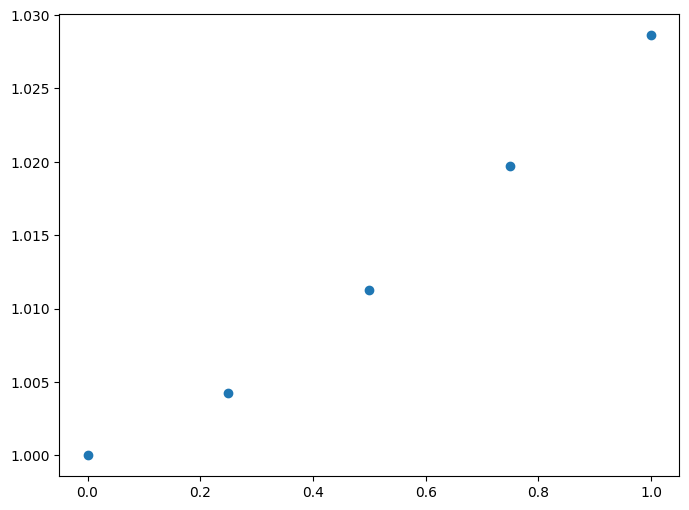

In [190]:
plt.figure(figsize=(8, 6))
plt.scatter(us, ss)
plt.show()

In [176]:
lengths=[10,]
n_particle=4

U = 0

H_dense = YbSOCHamiltonian(
    d=1,
    lengths=lengths,
    n_particle=n_particle,
    hbar=1,
    q=0.03,
    m_Yb=1,
    delta=0.08,
    omega_R=0.2,
    gamma=1j * U,
)

4845 4-particle states
75.70 KB per state (complex128)
358.19 MB for dense representation of an operator (complex128)


  0%|          | 0/4845 [00:00<?, ?it/s]

100%|██████████| 4845/4845 [00:00<00:00, 15360.49it/s]


In [178]:
eigenvalues, eigenvectors = jnp.linalg.eigh(H_dense)

E_r = jnp.real(eigenvalues)
E_i = jnp.imag(eigenvalues)

min_E_r_idx = jnp.argmin(E_r)
min_E_i_idx = jnp.argmin(E_i)

In [179]:
corr_mat = cooper_pair_corr(lengths, n_particle)
co = jnp.einsum('ji,jk,ki->i', eigenvectors.conj(), corr_mat, eigenvectors)

/home/pco0511/.local/lib/python3.12/site-packages/jax/_src/array.py:430: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(self._value, dtype=dtype, **kwds)


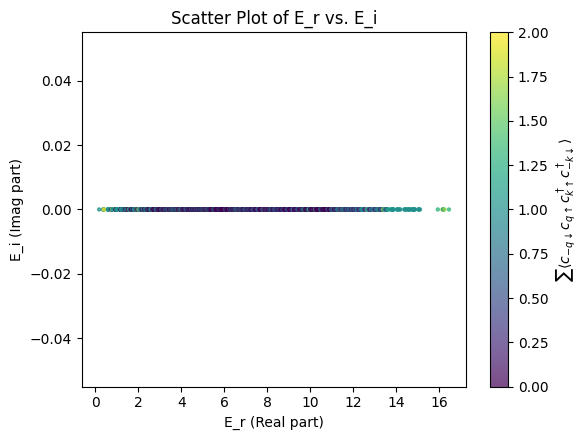

Array(1.02593326+0.j, dtype=complex128)

In [180]:

plt.figure(figsize=(6, 4.5))
scatter = plt.scatter(E_r, E_i, c=co, alpha=0.7, s=5)

cbar = plt.colorbar(scatter)
cbar.set_label('$\\sum\\langle{c_{-q\\downarrow} c_{q\\uparrow}}c_{k\\uparrow}^\\dagger c_{-k\\downarrow}^\\dagger\\rangle$')

plt.xlabel("E_r (Real part)")
plt.ylabel("E_i (Imag part)")
plt.title("Scatter Plot of E_r vs. E_i")

# plt.grid(True)
plt.tight_layout()
plt.show()

co[min_E_i_idx]

#### Multi sim

In [29]:
N = 51
corr_Er_min = np.empty((N,))
corr_Ei_min = np.empty((N,))

lengths = [8,]
n_particle = 4

omegas = np.linspace(0, 1, N)


for idx, omega in enumerate(tqdm.tqdm(omegas)):
    H_dense = YbSOCHamiltonian(
        d=1,
        lengths=lengths,
        n_particle=n_particle,
        hbar=1,
        q=0.03,
        m_Yb = 1,
        delta = 0.08,
        omega_R = omega,
        gamma = 0.02,
        print_info=False,
        display_progress=False
    )
    eigenvalues, eigenvectors = jnp.linalg.eig(H_dense)

    E_r = jnp.real(eigenvalues)
    E_i = jnp.imag(eigenvalues)

    min_E_r_idx = jnp.argmin(E_r)
    min_E_i_idx = jnp.argmin(E_i)
    
    corr_mat = cooper_pair_corr(lengths, n_particle)
    co = jnp.einsum('ji,jk,ki->i', eigenvectors.conj(), corr_mat, eigenvectors)
    
    corr_Er_min[idx] = co[min_E_r_idx].astype(jnp.float64)
    corr_Ei_min[idx] = co[min_E_i_idx].astype(jnp.float64)


100%|██████████| 51/51 [03:11<00:00,  3.76s/it]


In [172]:
plt.figure()
plt.scatter(omegas, corr_Er_min, label=f"ground state", s=6)
plt.scatter(omegas, corr_Ei_min, label=f"min $E_i$", s=6)
plt.xlabel("$\\Omega_R$")
plt.ylabel("$\\sum_{k, q}\\langle c_{\\downarrow}(-q)c_{\\uparrow}(q)c_{\\uparrow}^\\dagger(k)c_{\\downarrow}^\\dagger(-k)\\rangle$")
plt.legend()
plt.grid()
plt.show()

NameError: name 'omegas' is not defined

<Figure size 640x480 with 0 Axes>

### multi multi

In [151]:
sim_num = 2

#### diagonalize & save

In [ ]:
N = 51
corr_Er_min = np.empty((7, N))
corr_Ei_min = np.empty((7, N))

gammas = np.linspace(0, 0.5, N)
lengths = [8,]

data_root = f"/home/pco0511/yb-soc-two-body-loss/data/sim{sim_num}"
os.makedirs(data_root, exist_ok=True)

for n_particle in range(1, 7):
    subdir = os.path.join(data_root, f"dim8_npar{n_particle}_gamma-linsp0-0.5-51")
    os.makedirs(subdir, exist_ok=True)
    for idx, gamma in tqdm.tqdm(enumerate(gammas)):
        H_dense = YbSOCHamiltonian(
            d=1,
            lengths=lengths,
            n_particle=n_particle,
            hbar=1,
            q=0.03,
            m_Yb=0.01,
            delta=0.08,
            omega_R=0.2,
            gamma=gamma,
            print_info=False,
            display_progress=False
        )
        eigenvalues, eigenvectors = jnp.linalg.eig(H_dense)
        
        np.save(
            os.path.join(subdir, f"eigenvalues_{idx}.npy"),
            eigenvalues
        )
        np.save(
            os.path.join(subdir, f"eigenvectors_{idx}.npy"),
            eigenvectors
        )

        E_r = jnp.real(eigenvalues)
        E_i = jnp.imag(eigenvalues)

        min_E_r_idx = jnp.argmin(E_r)
        min_E_i_idx = jnp.argmin(E_i)


        corr = cooper_pair_corr_diag(lengths, n_particle)
        probs = jnp.abs(eigenvectors) ** 2
        co = jnp.einsum('i,ij->j', corr, probs)

        # corr_mat = cooper_pair_corr(lengths, n_particle)
        # co = jnp.einsum('ji,jk,ki->i', eigenvectors.conj(), corr_mat, eigenvectors)

        corr_Er_min[n_particle-1, idx] = co[min_E_r_idx].astype(jnp.float64)
        corr_Ei_min[n_particle-1, idx] = co[min_E_i_idx].astype(jnp.float64)


In [ ]:
data_root = f"/home/pco0511/yb-soc-two-body-loss/data/sim{sim_num}"
np.save("/home/pco0511/yb-soc-two-body-loss/data/sim2/gamma.npy", gammas)
np.save(os.path.join(data_root, "minEr.npy"), corr_Er_min)
np.save(os.path.join(data_root, "minEi.npy"), corr_Ei_min)

#### load data

In [171]:
N = 51
corr_Er_min = np.empty((7, N))
corr_Ei_min = np.empty((7, N))

data_root = f"/home/pco0511/yb-soc-two-body-loss/data/sim{sim_num}"

gammas = np.load(os.path.join(data_root, "gamma.npy"))
lengths = [8,]

for n_particle in range(1, 7):
    subdir = os.path.join(data_root, f"dim8_npar{n_particle}_gamma-linsp0-0.5-51")
    os.makedirs(subdir, exist_ok=True)
    figdir = os.path.join(subdir, f"figures")
    os.makedirs(figdir, exist_ok=True)
    for idx, gamma in tqdm.tqdm(enumerate(gammas)):
        eigenvalues = np.load(os.path.join(subdir, f"eigenvalues_{idx}.npy"))
        eigenvectors = np.load(os.path.join(subdir, f"eigenvectors_{idx}.npy"))

        corr_mat = cooper_pair_corr(lengths, n_particle)
        co = jnp.real(jnp.einsum('ji,jk,ki->i', eigenvectors.conj(), corr_mat, eigenvectors))

        # draw_ErEi_scatter(
        #     eigenvalues, 
        #     eigenvectors, 
        #     co,
        #     f"$\\gamma={gamma:.2f}$",
        #     os.path.join(figdir, f"{idx}.png")
        # )

        E_r = jnp.real(eigenvalues)
        E_i = jnp.imag(eigenvalues)

        # min_E_r_idx = jnp.argmin(E_r)
        # min_E_i_idx = jnp.argmin(E_i)

        max_E_r_idx = jnp.argmax(E_r)
        max_E_i_idx = jnp.argmax(E_i)


        corr = cooper_pair_corr_diag(lengths, n_particle)
        probs = jnp.abs(eigenvectors) ** 2
        co = jnp.einsum('i,ij->j', corr, probs)

        # corr_mat = (lengths, n_particle)
        # co = jnp.einsum('cooper_pair_corrji,jk,ki->i', eigenvectors.conj(), corr_mat, eigenvectors)

        corr_Er_min[n_particle-1, idx] = co[max_E_r_idx].astype(jnp.float64)
        corr_Ei_min[n_particle-1, idx] = co[max_E_i_idx].astype(jnp.float64)

0it [00:00, ?it/s]

51it [00:00, 190.94it/s]
51it [00:00, 182.06it/s]
51it [00:00, 74.69it/s]
51it [00:06,  7.38it/s]
51it [01:56,  2.29s/it]
51it [08:42, 10.24s/it]


In [148]:
data_root = f"/home/pco0511/yb-soc-two-body-loss/data/sim{sim_num}"

gammas = np.load(os.path.join(data_root, "gamma.npy"))
corr_Er_min = np.load(os.path.join(data_root, "minEr.npy"))
corr_Ei_min = np.load(os.path.join(data_root, "minEi.npy"))

FileNotFoundError: [Errno 2] No such file or directory: '/home/pco0511/yb-soc-two-body-loss/data/sim5/gamma.npy'

In [173]:
corr_Ei_min

array([[7.        , 7.        , 7.        , 7.        , 7.        ,
        7.        , 7.        , 7.        , 7.        , 7.        ,
        7.        , 7.        , 7.        , 7.        , 7.        ,
        7.        , 7.        , 7.        , 7.        , 7.        ,
        7.        , 7.        , 7.        , 7.        , 7.        ,
        7.        , 7.        , 7.        , 7.        , 7.        ,
        7.        , 7.        , 7.        , 7.        , 7.        ,
        7.        , 7.        , 7.        , 7.        , 7.        ,
        7.        , 7.        , 7.        , 7.        , 7.        ,
        7.        , 7.        , 7.        , 7.        , 7.        ,
        7.        ],
       [6.        , 6.        , 6.        , 6.        , 6.        ,
        6.        , 6.        , 6.        , 6.        , 6.        ,
        6.        , 6.        , 6.        , 6.        , 6.        ,
        6.        , 6.        , 6.        , 6.        , 6.        ,
        6.        , 6.     

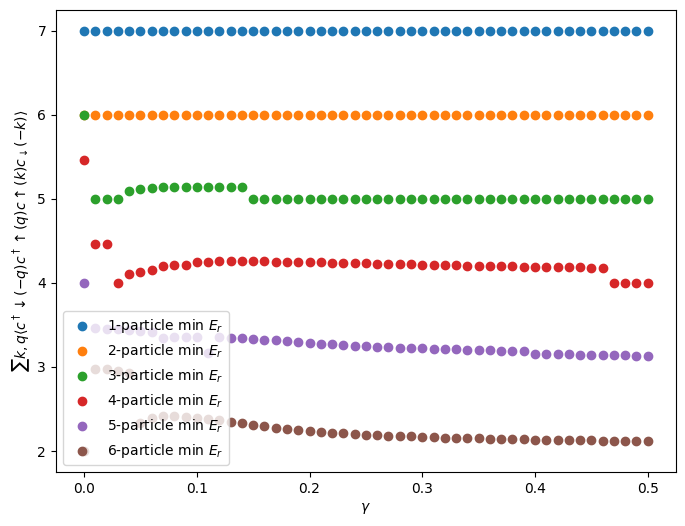

In [175]:
plt.figure(figsize=(8, 6))
for i in range(1, 7):
    # plt.scatter(gammas, corr_Er_min[i - 1], label=f"{i}-particle ground state")
    plt.scatter(gammas, corr_Ei_min[i - 1], label=f"{i}-particle min $E_r$")

plt.xlabel("$\\gamma$")
plt.ylabel("$\\sum{k, q}\\langle c^\\dagger{\\downarrow}(-q)c^\\dagger{\\uparrow}(q)c{\\uparrow}(k)c_{\\downarrow}(-k)\\rangle$")
plt.legend()
plt.show()

In [ ]:
gammas

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 ])

$$\sum_{k, q}\langle c^\dagger_{\downarrow}(-q)c^\dagger_{\uparrow}(q)c_{\uparrow}(k)c_{\downarrow}(-k)\rangle$$